In [1]:
import torch
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
import pandas as pd

# Load model and tokenizer
model_path = '../models/distilbert_final'

print("Loading model...")
tokenizer = DistilBertTokenizer.from_pretrained(model_path)
model = DistilBertForSequenceClassification.from_pretrained(model_path)

# Set to evaluation mode
model.eval()

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

print(f"✅ Model loaded from: {model_path}")
print(f"✅ Using device: {device}")
print(f"✅ Model parameters: {model.num_parameters():,}")

Loading model...
✅ Model loaded from: ../models/distilbert_final
✅ Using device: cpu
✅ Model parameters: 66,955,010


In [2]:
def predict_news(text, return_probabilities=True):
    """
    Predict if news article is FAKE or TRUE
    
    Args:
        text (str): Article text
        return_probabilities (bool): Return probability scores
        
    Returns:
        dict: Prediction results
    """
    # Tokenize
    inputs = tokenizer(
        text,
        truncation=True,
        padding=True,
        max_length=512,
        return_tensors='pt'
    )
    
    # Move to device
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    # Predict
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=-1)
        prediction = torch.argmax(probs, dim=-1).item()
    
    # Format results
    result = {
        'prediction': 'TRUE' if prediction == 1 else 'FAKE',
        'prediction_label': prediction,
        'confidence': probs[0][prediction].item() * 100,
    }
    
    if return_probabilities:
        result['probabilities'] = {
            'fake': probs[0][0].item() * 100,
            'true': probs[0][1].item() * 100
        }
    
    return result

print("✅ Prediction function created!")

✅ Prediction function created!


In [3]:
# Test Article 1: Known FAKE news style
fake_article = """
BREAKING: Scientists Discover That Eating Chocolate Every Day 
Makes You Live Forever! Doctors Hate This One Simple Trick!

A new study from the University of Nowhere has found that eating 
5 pounds of chocolate daily will extend your life by 200 years. 
Big Pharma doesn't want you to know this secret! Share this before 
they delete it!
"""

# Test Article 2: Known TRUE news style
true_article = """
WASHINGTON (Reuters) - The Federal Reserve announced today that 
interest rates will remain unchanged at current levels. The decision 
comes after careful analysis of economic indicators including inflation 
rates and employment data. Federal Reserve Chairman stated that the 
committee will continue to monitor economic conditions closely and 
make adjustments as necessary to maintain economic stability.
"""

print("="*60)
print("TEST 1: FAKE NEWS STYLE ARTICLE")
print("="*60)
print(f"Article: {fake_article[:200]}...\n")
result1 = predict_news(fake_article)
print(f"Prediction: {result1['prediction']}")
print(f"Confidence: {result1['confidence']:.2f}%")
print(f"Probabilities:")
print(f"  Fake: {result1['probabilities']['fake']:.2f}%")
print(f"  True: {result1['probabilities']['true']:.2f}%")

print("\n" + "="*60)
print("TEST 2: TRUE NEWS STYLE ARTICLE")
print("="*60)
print(f"Article: {true_article[:200]}...\n")
result2 = predict_news(true_article)
print(f"Prediction: {result2['prediction']}")
print(f"Confidence: {result2['confidence']:.2f}%")
print(f"Probabilities:")
print(f"  Fake: {result2['probabilities']['fake']:.2f}%")
print(f"  True: {result2['probabilities']['true']:.2f}%")

TEST 1: FAKE NEWS STYLE ARTICLE
Article: 
BREAKING: Scientists Discover That Eating Chocolate Every Day 
Makes You Live Forever! Doctors Hate This One Simple Trick!

A new study from the University of Nowhere has found that eating 
5 pounds ...

Prediction: FAKE
Confidence: 99.99%
Probabilities:
  Fake: 99.99%
  True: 0.01%

TEST 2: TRUE NEWS STYLE ARTICLE
Article: 
WASHINGTON (Reuters) - The Federal Reserve announced today that 
interest rates will remain unchanged at current levels. The decision 
comes after careful analysis of economic indicators including in...

Prediction: TRUE
Confidence: 100.00%
Probabilities:
  Fake: 0.00%
  True: 100.00%


In [4]:
# Load your test data
df = pd.read_csv('../data/processed/cleaned_news_data.csv')

# Get some random samples
import random
random.seed(42)

# Get 5 fake and 5 true articles
fake_samples = df[df['label'] == 0].sample(5)
true_samples = df[df['label'] == 1].sample(5)

print("="*60)
print("TESTING ON REAL DATASET SAMPLES")
print("="*60)

correct_predictions = 0
total_predictions = 0

print("\n📰 FAKE NEWS SAMPLES:\n")
for idx, row in fake_samples.iterrows():
    text = row['text']
    actual = 'FAKE'
    
    result = predict_news(text)
    predicted = result['prediction']
    confidence = result['confidence']
    
    is_correct = (predicted == actual)
    correct_predictions += is_correct
    total_predictions += 1
    
    status = "✅" if is_correct else "❌"
    print(f"{status} Title: {row['title'][:60]}...")
    print(f"   Predicted: {predicted} ({confidence:.1f}% confidence)")
    print()

print("\n📰 TRUE NEWS SAMPLES:\n")
for idx, row in true_samples.iterrows():
    text = row['text']
    actual = 'TRUE'
    
    result = predict_news(text)
    predicted = result['prediction']
    confidence = result['confidence']
    
    is_correct = (predicted == actual)
    correct_predictions += is_correct
    total_predictions += 1
    
    status = "✅" if is_correct else "❌"
    print(f"{status} Title: {row['title'][:60]}...")
    print(f"   Predicted: {predicted} ({confidence:.1f}% confidence)")
    print()

print("="*60)
print(f"Accuracy on samples: {correct_predictions}/{total_predictions} ({correct_predictions/total_predictions*100:.1f}%)")
print("="*60)

TESTING ON REAL DATASET SAMPLES

📰 FAKE NEWS SAMPLES:

✅ Title: OBAMA BLAMES RUSSIA For Hillary’s Loss, But NEW HARVARD STUD...
   Predicted: FAKE (100.0% confidence)

✅ Title:  WATCH: CNN Smacks Down Rudy Giuliani So Hard He Starts Blam...
   Predicted: FAKE (100.0% confidence)

✅ Title: STEP ASIDE FOX NEWS, IT’S NOT ABOUT YOU!...
   Predicted: FAKE (100.0% confidence)

✅ Title: An OBAMA “LOW LEVEL OFFENDER” Gets Early Release From Prison...
   Predicted: FAKE (100.0% confidence)

✅ Title: OBAMA USES WORLD STAGE To Announce Plans For Executive Actio...
   Predicted: FAKE (100.0% confidence)


📰 TRUE NEWS SAMPLES:

✅ Title: House tax panel chair: corporate tax cut may take 'several s...
   Predicted: TRUE (100.0% confidence)

✅ Title: Japan PM Abe's ratings regain 50 percent amid North Korea se...
   Predicted: TRUE (100.0% confidence)

✅ Title: Biden does not see Trump undoing much of environmental recor...
   Predicted: TRUE (100.0% confidence)

✅ Title: Four other suspects in killin

Testing on 100 random articles...
BATCH TEST RESULTS (100 articles)

Accuracy: 1.0000 (100.00%)

Classification Report:
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00        42
        True       1.00      1.00      1.00        58

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



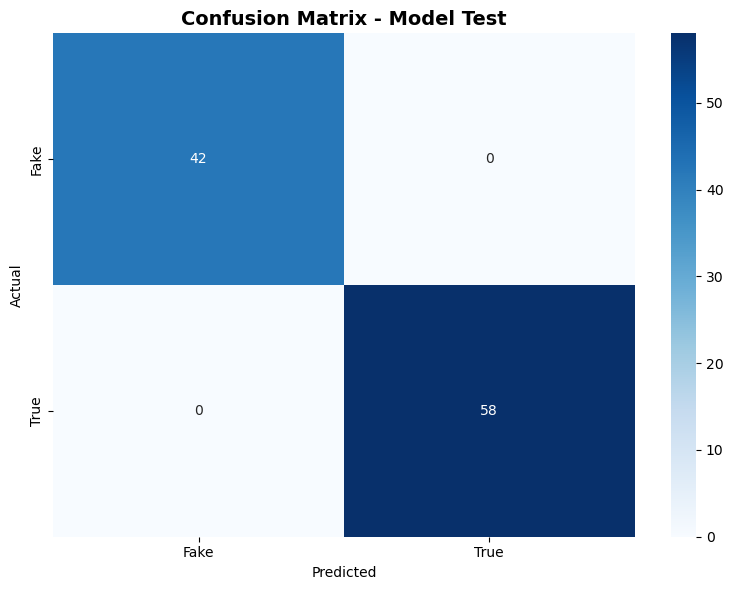


✅ Model is working correctly!


In [5]:
# Test on larger batch
print("Testing on 100 random articles...")

test_sample = df.sample(100, random_state=42)
predictions = []
actuals = []

for idx, row in test_sample.iterrows():
    result = predict_news(row['text'])
    predictions.append(1 if result['prediction'] == 'TRUE' else 0)
    actuals.append(row['label'])

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

accuracy = accuracy_score(actuals, predictions)

print("="*60)
print("BATCH TEST RESULTS (100 articles)")
print("="*60)
print(f"\nAccuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print("\nClassification Report:")
print(classification_report(actuals, predictions, target_names=['Fake', 'True']))

# Confusion Matrix
cm = confusion_matrix(actuals, predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake', 'True'],
            yticklabels=['Fake', 'True'])
plt.title('Confusion Matrix - Model Test', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print(f"\n✅ Model is working correctly!")

In [6]:
def test_custom_article():
    """
    Interactive function to test your own articles
    """
    print("="*60)
    print("CUSTOM ARTICLE TESTING")
    print("="*60)
    print("Paste an article (or type 'quit' to exit):\n")
    
    article = input()
    
    if article.lower() == 'quit':
        return
    
    result = predict_news(article)
    
    print("\n" + "="*60)
    print("YOUR ARTICLE")
    print("="*60)
    print(article)
    
    print("\n" + "="*60)
    print("PREDICTION RESULT")
    print("="*60)
    print(f"Prediction: {result['prediction']}")
    print(f"Confidence: {result['confidence']:.2f}%")
    print(f"\nProbability Breakdown:")
    print(f"  Fake News: {result['probabilities']['fake']:.2f}%")
    print(f"  True News: {result['probabilities']['true']:.2f}%")
    print("="*60)

# Run interactive test
test_custom_article()

CUSTOM ARTICLE TESTING
Paste an article (or type 'quit' to exit):



Running predictions on the test sample (this may take a bit)...

=== Summary Metrics ===
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1: 1.0000
ROC AUC: 1.0000
Avg Precision (AP): 1.0000

=== Classification Report ===

=== Summary Metrics ===
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1: 1.0000
ROC AUC: 1.0000
Avg Precision (AP): 1.0000

=== Classification Report ===


,precision,recall,f1-score,support
Fake,1.0,1.0,1.0,42.0
True,1.0,1.0,1.0,58.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,100.0
weighted avg,1.0,1.0,1.0,100.0


C:\Users\karbi\AppData\Local\Temp\ipykernel_18844\960798732.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x='Metric', y='Value', data=metrics_df, palette=palette, width=0.6, edgecolor='black')
C:\Users\karbi\AppData\Local\Temp\ipykernel_18844\960798732.py:95: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\karbi\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\karbi\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


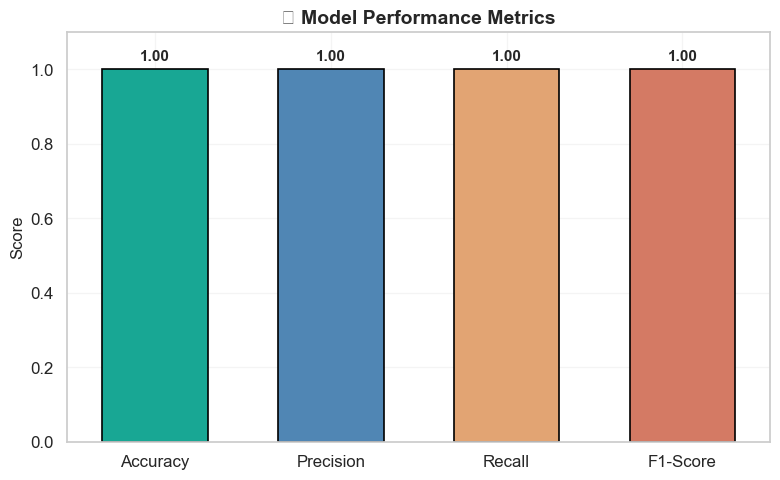

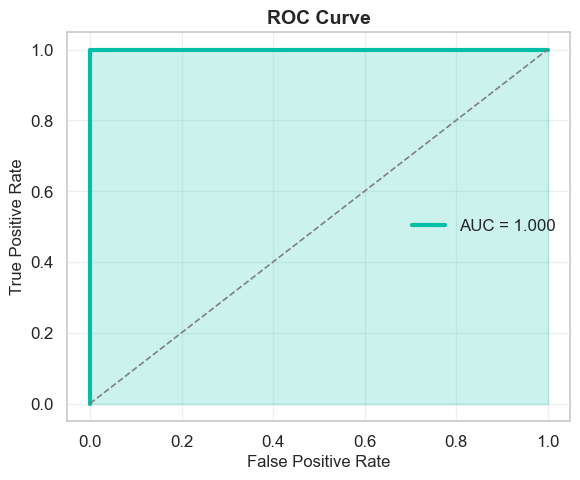

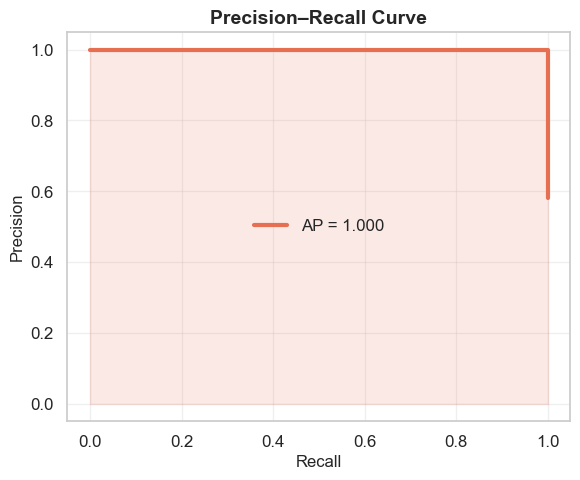

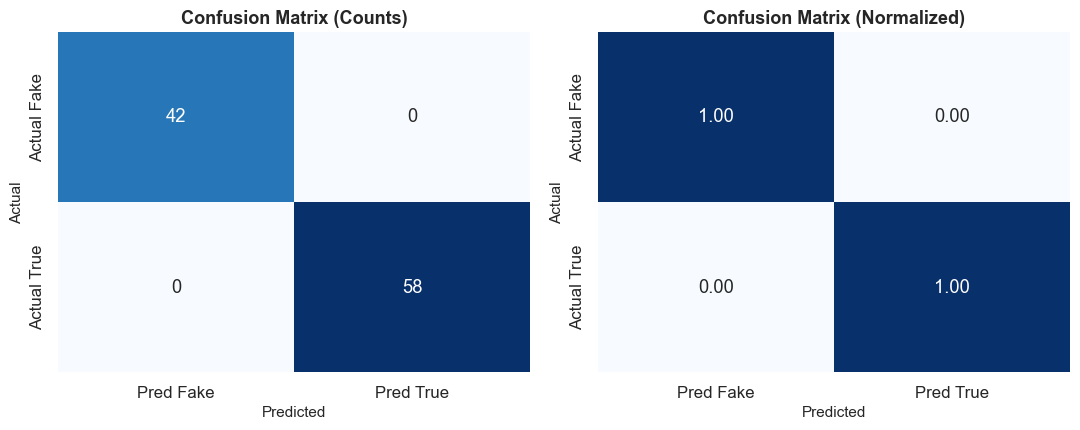


✅ Evaluation and enhanced plots complete.


In [10]:
# Extra evaluation and polished plots (visually enhanced)
# -------------------------------------------------------
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, classification_report,
    confusion_matrix, roc_curve, precision_recall_curve
)

# Ensure df exists - try to load if not
try:
    _ = df
except NameError:
    print("`df` not found in the notebook namespace; attempting to load from file...")
    df = pd.read_csv('../data/processed/cleaned_news_data.csv')

# Sample a test set (same seed for reproducibility)
test_sample = df.sample(100, random_state=42)

y_true, y_pred, y_score = [], [], []

print("Running predictions on the test sample (this may take a bit)...")
for _, row in test_sample.iterrows():
    res = predict_news(row['text'])
    prob_true = res.get('probabilities', {}).get('true', None)
    if prob_true is None:
        prob_true = res['confidence'] if res['prediction'] == 'TRUE' else (100 - res['confidence'])
    prob_true = float(prob_true) / 100.0

    pred = 1 if res['prediction'] == 'TRUE' else 0
    y_true.append(int(row['label']))
    y_pred.append(pred)
    y_score.append(prob_true)

# Convert to numpy arrays
y_true, y_pred, y_score = np.array(y_true), np.array(y_pred), np.array(y_score)

# Compute metrics
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, zero_division=0)
rec = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
try:
    roc_auc = roc_auc_score(y_true, y_score)
except Exception:
    roc_auc = None
avg_prec = average_precision_score(y_true, y_score)

report = classification_report(y_true, y_pred, target_names=['Fake', 'True'], output_dict=True, zero_division=0)
df_report = pd.DataFrame(report).transpose()

print("\n=== Summary Metrics ===")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1: {f1:.4f}")
if roc_auc is not None:
    print(f"ROC AUC: {roc_auc:.4f}")
else:
    print("ROC AUC: N/A (only one class present in y_true?)")
print(f"Avg Precision (AP): {avg_prec:.4f}")

print("\n=== Classification Report ===")
display(df_report)

# ---------------------------
# Enhanced Visualization
# ---------------------------
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)
palette = ["#00BFA6", "#3F88C5", "#F4A261", "#E76F51"]

# 1) Metrics bar chart (polished)
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Value': [acc, prec, rec, f1]
})

plt.figure(figsize=(8, 5))
bars = sns.barplot(x='Metric', y='Value', data=metrics_df, palette=palette, width=0.6, edgecolor='black')

# Rounded bar tips + annotations
for i, v in enumerate(metrics_df['Value']):
    bars.patches[i].set_linewidth(1.2)
    bars.patches[i].set_edgecolor('black')
    plt.text(i, v + 0.015, f"{v:.2f}", ha='center', va='bottom', fontsize=11, fontweight='semibold')

plt.ylim(0, 1.1)
plt.title("📊 Model Performance Metrics", fontsize=14, fontweight='bold')
plt.xlabel("")
plt.ylabel("Score", fontsize=12)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# 2) ROC Curve (smooth, minimal, elegant)
if roc_auc is not None:
    fpr, tpr, _ = roc_curve(y_true, y_score)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color="#00BFA6", lw=3, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray", lw=1.2)
    plt.fill_between(fpr, tpr, alpha=0.2, color="#00BFA6")
    plt.xlabel("False Positive Rate", fontsize=12)
    plt.ylabel("True Positive Rate", fontsize=12)
    plt.title("ROC Curve", fontsize=14, fontweight='bold')
    plt.legend(frameon=False)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# 3) Precision-Recall Curve (refined)
precision, recall, _ = precision_recall_curve(y_true, y_score)
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, color="#E76F51", lw=3, label=f"AP = {avg_prec:.3f}")
plt.fill_between(recall, precision, alpha=0.15, color="#E76F51")
plt.xlabel("Recall", fontsize=12)
plt.ylabel("Precision", fontsize=12)
plt.title("Precision–Recall Curve", fontsize=14, fontweight='bold')
plt.legend(frameon=False)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 4) Confusion Matrix (counts + normalized, side-by-side)
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-9)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=['Pred Fake', 'Pred True'], yticklabels=['Actual Fake', 'Actual True'])
axes[0].set_title("Confusion Matrix (Counts)", fontweight='bold', fontsize=13)
axes[0].set_xlabel("Predicted", fontsize=11)
axes[0].set_ylabel("Actual", fontsize=11)

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', cbar=False, ax=axes[1],
            xticklabels=['Pred Fake', 'Pred True'], yticklabels=['Actual Fake', 'Actual True'])
axes[1].set_title("Confusion Matrix (Normalized)", fontweight='bold', fontsize=13)
axes[1].set_xlabel("Predicted", fontsize=11)
axes[1].set_ylabel("Actual", fontsize=11)

plt.tight_layout()
plt.show()

print("\n✅ Evaluation and enhanced plots complete.")


In [8]:
print(test_sample['label'].value_counts())

label
1    58
0    42
Name: count, dtype: int64


In [9]:
pd.crosstab(y_true, y_pred, rownames=['Actual'], colnames=['Predicted'])


Predicted,0,1
Actual,,
0,42,0
1,0,58
